Torch using device: cpu
JAX devices: [CpuDevice(id=0)]


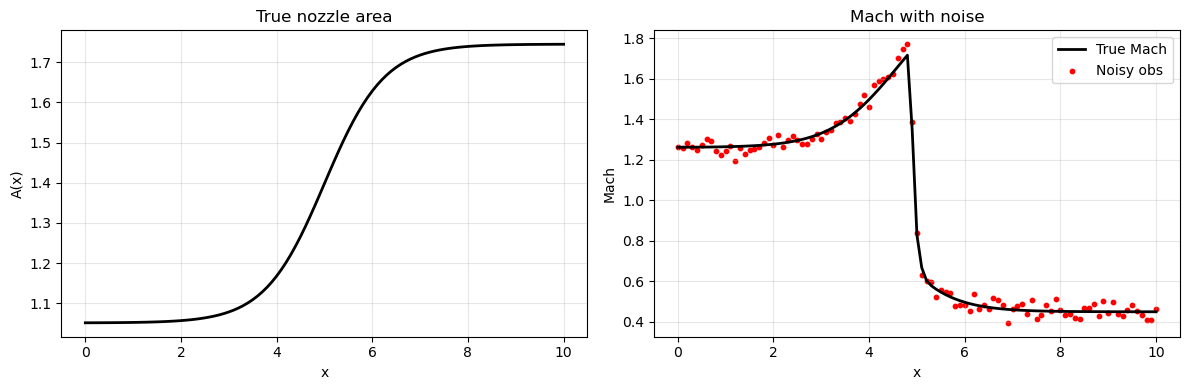

In [ ]:
# ===============================================================
# Imports + CPU-only setup + JAX CFD solver
# ===============================================================

from functools import partial
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU

import jax
import jax.numpy as jnp
from jax import lax

import numpy as onp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from numpyro.infer.initialization import init_to_value

import torch
device_torch = torch.device("cpu")
print("Torch using device:", device_torch)

jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())


# ------------------ Forward solver (JAX CFD) ------------------
def DeltaCal_jnp(x):
    dx = jnp.zeros_like(x)
    dx = dx.at[:-1].set(x[1:] - x[:-1])
    dx = dx.at[-1].set(dx[-2])
    return dx

def EnergyCal_jnp(rho, u, P, gamma):
    return P / (gamma - 1.0) + 0.5 * rho * u**2

def ConservCal_jnp(rho, u, E, A):
    Q0 = rho * A
    Q1 = rho * u * A
    Q2 = E   * A
    return jnp.stack([Q0, Q1, Q2], axis=0)

def PrimCal_jnp(Q, A):
    rho = Q[0] / A
    u   = Q[1] / Q[0]
    E   = Q[2] / A
    return rho, u, E

def PressureCal_jnp(rho, u, E, gamma):
    return (gamma - 1.0) * (E - 0.5 * rho * u**2)

def FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma):
    N = u.size
    zeros = jnp.zeros(N)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c

    mask_sub     = jnp.abs(M) < 1.0
    mask_le_neg1 = M <= -1.0
    mask_gt_pos1 = M >  1.0

    PP  = jnp.where(mask_sub, 0.5*(1+M)*P, 0.0)
    PN  = jnp.where(mask_sub, 0.5*(1-M)*P, 0.0)
    PuP = jnp.where(mask_sub, 0.5*(u+c)*P, 0.0)
    PuN = jnp.where(mask_sub, 0.5*(u-c)*P, 0.0)

    PP  = jnp.where(mask_gt_pos1, P,  PP)
    PuP = jnp.where(mask_gt_pos1, u*P, PuP)
    PN  = jnp.where(mask_le_neg1, P,  PN)
    PuN = jnp.where(mask_le_neg1, u*P, PuN)

    Fp0 = jnp.where(u>0, rho*u*A, 0.0)
    Fp1 = jnp.where(u>0, (rho*u**2+PP)*A, PP*A)
    Fp2 = jnp.where(u>0, (u*E+PuP)*A,    PuP*A)

    Fn0 = jnp.where(u<0, rho*u*A, 0.0)
    Fn1 = jnp.where(u<0, (rho*u**2+PN)*A, PN*A)
    Fn2 = jnp.where(u<0, (u*E+PuN)*A,    PuN*A)

    FP = jnp.stack([Fp0, Fp1, Fp2], axis=0)
    FN = jnp.stack([Fn0, Fn1, Fn2], axis=0)
    H  = jnp.stack([zeros, P*dAdx, zeros], axis=0)
    return FP, FN, H

def TimeStep_jnp(dx, rho, u, P, cfl, gamma):
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    cmax = jnp.max(jnp.abs(u) + c)
    return cfl * dx[1] / cmax

@partial(jax.jit, static_argnames=("gamma",))
def apply_bc(rho, u, P, E, gamma):
    # inlet (supersonic)
    rho = rho.at[0].set(0.5008261)
    u   = u.at[0].set(1.0991840)
    P   = P.at[0].set(0.2712900)
    E   = E.at[0].set(EnergyCal_jnp(rho[0], u[0], P[0], gamma))

    # outlet (subsonic: fixed P, extrapolated rho,u)
    rho = rho.at[-1].set(2.0 * rho[-2] - rho[-3])
    u   = u.at[-1].set(2.0 * u[-2]   - u[-3])
    P   = P.at[-1].set(0.5156000)
    E   = E.at[-1].set(EnergyCal_jnp(rho[-1], u[-1], P[-1], gamma))
    return rho, u, P, E

def upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt):
    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    rho, u, P, E = apply_bc(rho, u, P, E, gamma)
    Q = ConservCal_jnp(rho, u, E, A)
    FP, FN, H = FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma)

    def update_col(i, Q):
        Qi = Q[:, i]
        dF = (FP[:, i] - FP[:, i-1] + FN[:, i+1] - FN[:, i])
        Qi_new = Qi - (dt / dx[i]) * dF + dt * H[:, i]
        return Q.at[:, i].set(Qi_new)

    N = A.size
    Q_new = lax.fori_loop(1, N-1, update_col, Q)
    return Q_new

@partial(jax.jit, static_argnames=("n_steps","gamma","cfl"))
def forward_only_jax(x, A, n_steps=5000, gamma=1.4, cfl=0.9):
    x = jnp.asarray(x); A = jnp.asarray(A)
    N = A.size

    dAdx0  = (A[1]  - A[0])  / (x[1]  - x[0])
    dAdxN1 = (A[-1] - A[-2]) / (x[-1] - x[-2])
    dAdx_mid = (A[2:] - A[:-2]) / (x[2:] - x[:-2])
    dAdx = jnp.concatenate([dAdx0[None], dAdx_mid, dAdxN1[None]])

    dx = DeltaCal_jnp(x)

    rho = jnp.ones(N) * 0.7511383
    u   = jnp.ones(N) * 0.4416178
    P   = jnp.ones(N) * 0.2156000
    E   = EnergyCal_jnp(rho, u, P, gamma)
    Q   = ConservCal_jnp(rho, u, E, A)

    def body_fun(step, Q):
        rho0, u0, E0 = PrimCal_jnp(Q, A)
        P0 = PressureCal_jnp(rho0, u0, E0, gamma)
        dt = TimeStep_jnp(dx, rho0, u0, P0, cfl, gamma)
        return upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt)

    Q = lax.fori_loop(0, n_steps, body_fun, Q)

    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c
    return rho, u, P, M


# ===============================================================
# Observation data generation (truth + noisy Mach)
# ===============================================================

def A_true_fn(x):
    return 1.398 + 0.347 * jnp.tanh(0.8 * x - 4.0)

# Grid / solver params
N       = 101
x       = jnp.linspace(0.0, 10.0, N, dtype=jnp.float32)
L       = float(x[-1])
gamma   = 1.4
cfl     = 0.9
n_steps = 5000

# Truth area + forward truth Mach
A_true  = A_true_fn(x)
A0_val  = float(A_true[0])
A10_val = float(A_true[-1])

rho_true, u_true, P_true, M_true = forward_only_jax(x, A_true, n_steps=n_steps, gamma=gamma, cfl=cfl)

# Add noise to Mach observations
rng = onp.random.default_rng(0)
noise_sigma = 0.03
M_obs = onp.array(M_true) + noise_sigma * rng.standard_normal((N,))

# Use all points 
obs_idx = onp.arange(N, dtype=onp.int32)

# Quick check plot
x_np = onp.asarray(x)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_np, onp.asarray(A_true), "k-", lw=2)
plt.xlabel("x"); plt.ylabel("A(x)"); plt.title("True nozzle area"); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(x_np, onp.asarray(M_true), "k-", lw=2, label="True Mach")
plt.scatter(x_np, M_obs, s=10, c="r", label="Noisy obs")
plt.xlabel("x"); plt.ylabel("Mach"); plt.title("Mach with noise")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------------------------------------------
# The sparsified data
# uniformly-spaced observation points ( 5, 10 , 20 , 40, 80 and 100)
# ---------------------------------------------------
Nobs = 10
obs_idx = onp.linspace(0, N-1, Nobs).round().astype(onp.int32)
obs_idx = onp.unique(obs_idx)  # safety

# Subsampled observations used in likelihood
x_np = onp.asarray(x)
x_obs = x_np[obs_idx]
M_obs = M_obs_full[obs_idx]

# # Quick check plot 
# plt.figure(figsize=(12,4))
# plt.subplot(1,2,1)
# plt.plot(x_np, onp.asarray(A_true), "k-", lw=2)
# plt.xlabel("x"); plt.ylabel("A(x)"); plt.title("True nozzle area"); plt.grid(alpha=0.3)

# plt.subplot(1,2,2)
# plt.plot(x_np, onp.asarray(M_true), "k-", lw=2, label="True Mach")
# plt.scatter(
#     x_obs, M_obs,
#     s=45,
#     facecolor="tab:red",
#     edgecolor="black",
#     linewidth=0.6,
#     alpha=0.75,
#     label=f"Noisy obs",
#     zorder=3
# )
# plt.xlabel("x"); plt.ylabel("Mach"); plt.title("Mach with sparse noise (Nobs=80)")
# plt.legend(); plt.grid(alpha=0.3)
# plt.tight_layout(); plt.show()


sample: 100%|██████████| 400/400 [43:00<00:00,  6.45s/it, 31 steps of size 8.15e-02. acc. prob=0.95]


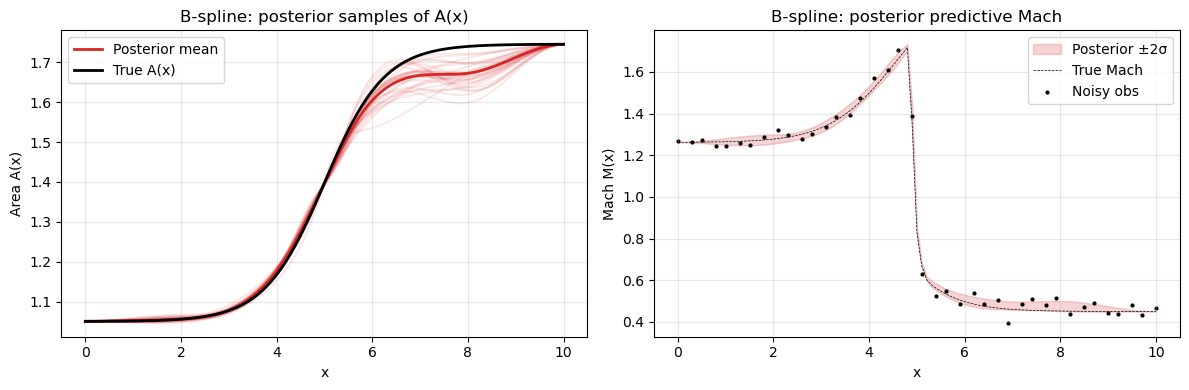


Saved B-spline results to: inverse_nozzle_bspline_40_20251214_230040.npz


In [ ]:
def clustered_knots_x(K, degree, x0, x1, center, width=1.2):
    """Clamped cubic knots with interior knots clustered around 'center'."""
    n_int = K - degree - 1
    if n_int <= 0:
        raise ValueError("K must satisfy K - degree - 1 >= 1")

    left  = max(x0 + 1e-6, center - width)
    right = min(x1 - 1e-6, center + width)

    n_center = max(2, int(0.7 * n_int))
    n_outer  = n_int - n_center
    n_left   = n_outer // 2
    n_right  = n_outer - n_left

    def seg(a, b, n):
        if n <= 0 or b <= a + 1e-9:
            return jnp.array([], dtype=jnp.float32)
        xs = jnp.linspace(a, b, n + 2, dtype=jnp.float32)[1:-1]
        return xs

    center_knots = seg(left, right, n_center)
    left_knots   = seg(x0, left, n_left)
    right_knots  = seg(right, x1, n_right)

    interior = jnp.sort(jnp.concatenate([left_knots, center_knots, right_knots], axis=0))
    knots = jnp.concatenate([
        jnp.full((degree+1,), x0, dtype=jnp.float32),
        interior,
        jnp.full((degree+1,), x1, dtype=jnp.float32),
    ])
    return knots

def bspline_basis_matrix_x(xv, K=10, degree=3, knots=None, x0=0.0, x1=10.0):
    if knots is None:
        n_spans = K - degree
        if n_spans > 1:
            interior = jnp.linspace(x0, x1, n_spans + 1, dtype=jnp.float32)[1:-1]
        else:
            interior = jnp.array([], dtype=jnp.float32)
        knots = jnp.concatenate([
            jnp.full((degree+1,), x0, dtype=jnp.float32),
            interior,
            jnp.full((degree+1,), x1, dtype=jnp.float32),
        ])
    m = knots.size - 1
    x = jnp.asarray(xv, dtype=jnp.float32)
    x = jnp.clip(x, x0, jnp.nextafter(x1, x0))
    xcol = x[:, None]

    left  = xcol >= knots[:-1]
    right = xcol <  knots[ 1:]
    Nloc = (left & right).astype(jnp.float32)

    N = Nloc
    for d in range(1, degree+1):
        i_count = m - d
        Lk  = knots[:i_count]; Rk  = knots[d:m]
        denomL = Rk - Lk
        a = jnp.where(denomL > 0, (xcol - Lk)/denomL, 0.0)

        Lk2 = knots[1:i_count+1]; Rk2 = knots[d+1:m+1]
        denomR = Rk2 - Lk2
        b = jnp.where(denomR > 0, (Rk2 - xcol)/denomR, 0.0)

        N = a * N[:, :i_count] + b * N[:, 1:i_count+1]
    return N, knots

def solve_endpoint_ctrls_x(A0, A1, dA0, dA1, K, degree, knots_x):
    """Endpoint value + slope constraints for clamped cubic spline."""
    p = degree
    c0, cKm1 = A0, A1
    Delta_left  = knots_x[p+1] - knots_x[1]
    Delta_right = knots_x[-2]  - knots_x[-(p+2)]
    c1   = c0   + (Delta_left  / p) * dA0
    cKm2 = cKm1 - (Delta_right / p) * dA1
    return c0, c1, cKm2, cKm1

# --- Demonstrate knots and baseline ---
K_bs   = 10
deg_bs = 3
x_c_fixed   = 5.0
cluster_width = 1.2

knots_demo = clustered_knots_x(K_bs, deg_bs, 0.0, L, center=x_c_fixed, width=cluster_width)
B_demo, knots_x_demo = bspline_basis_matrix_x(x, K=K_bs, degree=deg_bs,
                                              knots=knots_demo, x0=0.0, x1=L)

# Greville abscissae + smooth baseline shape
grev_demo = onp.array([(onp.array(knots_x_demo)[i+1:i+1+deg_bs]).mean()
                       for i in range(K_bs)], dtype=float)
s_demo    = onp.tanh(1.2 * (grev_demo - x_c_fixed))
s_demo    = 0.5 * (1.0 + s_demo)
c_base_demo = A0_val + (A10_val - A0_val) * s_demo
A_base_demo = B_demo @ jnp.array(c_base_demo, dtype=jnp.float32)

# plt.figure(figsize=(10,4))

# plt.subplot(1,2,1)
# plt.plot(x_np, A_true_np, 'k-', lw=2, label="True A(x)")
# plt.plot(x_np, onp.array(A_base_demo), 'C3--', lw=2, label="Baseline spline A(x)")
# plt.scatter(grev_demo, c_base_demo, c="C3", s=40, label="Control points (baseline)")
# # plt.axvline(x_c_fixed, ls="--", color="gray", alpha=0.5, label="Cluster center")
# plt.xlabel("x"); plt.ylabel("Area A(x)")
# plt.title("B-spline baseline vs true A(x)")
# plt.legend(); plt.grid(alpha=0.3)

# # plt.subplot(1,2,2)
# # # plt.stem(knots_demo, onp.ones_like(knots_demo), basefmt=" ", use_line_collection=True)
# # plt.axvline(x_c_fixed, ls="--", color="gray", alpha=0.5)
# # plt.xlabel("x"); plt.ylabel("Knot indicator")
# # plt.title("Clustered spline knots around throat")
# # plt.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

# %% 
# ===========================================
# NumPyro inverse model for B-spline A(x)
# ===========================================

def model_bspline_end_slope_Mach_subset(
    x_full, M_obs_sub, obs_idx, A0, A1, dA0, dA1, L=10.0,
    n_steps=5000, gamma=1.4, cfl=0.9,
    K=10, degree=3,
    sigma_prior=0.05,
    area_floor=1e-3,
    mono_lambda=25.0,
    prior_span=0.3,
    x_c=5.0,
    cluster_width=1.2
):
    # knots + basis
    knots = clustered_knots_x(K, degree, 0.0, L, center=x_c, width=cluster_width)
    B_full, knots_x = bspline_basis_matrix_x(x_full, K=K, degree=degree,
                                             knots=knots, x0=0.0, x1=L)

    # endpoint constraints
    c0, c1, cKm2, cKm1 = solve_endpoint_ctrls_x(A0, A1, dA0, dA1, K, degree, knots_x)

    # Greville abscissae & smooth baseline
    grev = jnp.array([(knots_x[i+1:i+1+degree]).mean() for i in range(K)], dtype=jnp.float32)
    s    = jnp.tanh(1.2 * (grev - x_c))
    s    = 0.5 * (1.0 + s)
    c_base = A0 + (A1 - A0) * s

    # interior deltas
    lo = -prior_span * jnp.ones((K-4,), dtype=jnp.float32)
    hi =  prior_span * jnp.ones((K-4,), dtype=jnp.float32)
    delta = numpyro.sample("delta", dist.Uniform(lo, hi))  # (K-4,)

    c_interior = c_base[2:-2] + delta
    c = jnp.concatenate([jnp.array([c0, c1]), c_interior, jnp.array([cKm2, cKm1])])
    numpyro.deterministic("c", c)

    # area & monotonicity prior
    A_full = jnp.clip(B_full @ c, a_min=area_floor, a_max=None)
    diffs = A_full[1:] - A_full[:-1]
    numpyro.factor("mono_prior", -mono_lambda * jnp.sum(jnp.square(jnp.minimum(diffs, 0.0))))

    # forward model -> Mach
    _, _, _, M_pred_full = forward_only_jax(x_full, A_full, n_steps=n_steps, gamma=gamma, cfl=cfl)
    M_pred = M_pred_full[obs_idx]

    # keep chains stable
    all_finite = jnp.isfinite(M_pred).all()
    numpyro.factor("nan_guard", jnp.where(all_finite, 0.0, -1e6))
    M_pred_safe = jnp.where(all_finite, M_pred, jnp.zeros_like(M_pred))

    sigma = numpyro.sample("sigma", dist.HalfNormal(sigma_prior))
    with numpyro.plate("data_sub", M_pred_safe.shape[0]):
        numpyro.sample("M_obs_sub", dist.Normal(M_pred_safe, sigma), obs=M_obs_sub)

# --- Run MCMC (B-spline model) ---
x_full_jnp  = x_full
obs_idx_jnp = jnp.array(obs_idx, dtype=jnp.int32)
M_obs_sub   = jnp.array(M_obs, dtype=jnp.float32)

init_params_bs = {
    "delta": jnp.zeros((K_bs-4,), dtype=jnp.float32),
    "sigma": jnp.array(0.05, dtype=jnp.float32),
}
nuts_bs = NUTS(
    model_bspline_end_slope_Mach_subset,
    init_strategy=init_to_value(values=init_params_bs),
    max_tree_depth=5,
    target_accept_prob=0.9,
)
mcmc_bs = MCMC(nuts_bs,
               num_warmup=100,
               num_samples=300,
               num_chains=1,
               progress_bar=True)
rng_key_bs = jax.random.PRNGKey(2)
mcmc_bs.run(
    rng_key_bs,
    x_full=x_full_jnp,
    M_obs_sub=M_obs_sub,
    obs_idx=obs_idx_jnp,
    A0=A0_val, A1=A10_val, dA0=dA0_val, dA1=dA10_val,
    L=L,
    n_steps=5000, gamma=1.4, cfl=0.9,
    K=K_bs, degree=deg_bs,
    sigma_prior=0.05,
    area_floor=1e-3,
    mono_lambda=25.0,
    prior_span=0.3,
    x_c=x_c_fixed,
    cluster_width=cluster_width,
)
samples_bs = mcmc_bs.get_samples()

# Rebuild basis with same knots for posterior
knots_bs = clustered_knots_x(K_bs, deg_bs, 0.0, L, center=x_c_fixed, width=cluster_width)
B_full_bs, _ = bspline_basis_matrix_x(x_full_jnp, K=K_bs, degree=deg_bs,
                                      knots=knots_bs, x0=0.0, x1=L)

c_samps = samples_bs["c"]         # (S, K_bs)
S_bs = c_samps.shape[0]
A_samps_bs = c_samps @ B_full_bs.T
A_bs_mu = jnp.mean(A_samps_bs, axis=0)
A_bs_sd = jnp.std(A_samps_bs, axis=0)

# Posterior Mach (B-spline)
S_pp = int(min(150, S_bs))
idx_pp = onp.linspace(0, S_bs-1, S_pp, dtype=int)
M_samps_bs = []
for s in idx_pp:
    A_draw = jnp.clip(A_samps_bs[s], 1e-3, None)
    _, _, _, M_pred = forward_only_jax(x_full_jnp, A_draw, n_steps=5000, gamma=1.4, cfl=0.9)
    M_samps_bs.append(M_pred)
M_samps_bs = jnp.stack(M_samps_bs, axis=0)
M_bs_mu = jnp.mean(M_samps_bs, axis=0)
M_bs_sd = jnp.std(M_samps_bs, axis=0)

# --- Intermediate plots: B-spline posterior ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
for s in range(0, S_bs, max(1, S_bs//30)):
    plt.plot(x_np, onp.array(A_samps_bs[s]), color="C3", alpha=0.1)
plt.plot(x_np, onp.array(A_bs_mu), "C3-", lw=2, label="Posterior mean")
plt.plot(x_np, A_true, "k-", lw=2, label="True A(x)")
plt.xlabel("x"); plt.ylabel("Area A(x)")
plt.title("B-spline: posterior samples of A(x)")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.fill_between(
    x_np,
    M_bs_mu - 2*onp.array(M_bs_sd),
    M_bs_mu + 2*onp.array(M_bs_sd),
    alpha=0.2, color="C3", label="Posterior ±2σ"
)
plt.plot(x_np, M_true, "k--", lw=0.5, label="True Mach")
plt.scatter(x_obs, M_obs, s=4, c="k", label="Noisy obs")
plt.xlabel("x"); plt.ylabel("Mach M(x)")
plt.title("B-spline: posterior predictive Mach")
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# SAVE B-SPLINE RESULTS (single .npz) 
# ==========================================================
import numpy as np
from datetime import datetime

save_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_npz  = f"inverse_nozzle_bspline_40_{save_tag}.npz"

# Make sure arrays are NumPy 
def _np(a):
    return np.asarray(a)

# Credible bands 
A_bs_mu_np = _np(A_bs_mu)
A_bs_sd_np = _np(A_bs_sd)
A_bs_lo_np = A_bs_mu_np - 2.0 * A_bs_sd_np
A_bs_hi_np = A_bs_mu_np + 2.0 * A_bs_sd_np

M_bs_mu_np = _np(M_bs_mu)
M_bs_sd_np = _np(M_bs_sd)
M_bs_lo_np = M_bs_mu_np - 2.0 * M_bs_sd_np
M_bs_hi_np = M_bs_mu_np + 2.0 * M_bs_sd_np

# posterior draws 
delta_samps = samples_bs["delta"]         # (S, K-4)
sigma_post  = samples_bs["sigma"]         # (S,)
c_samps_np  = _np(c_samps)                # (S, K)

# Store obs index + x_obs if you used subset (if not defined, compute)
try:
    x_obs_np = _np(x_obs)
except NameError:
    x_obs_np = _np(x_np[_np(obs_idx)])

np.savez_compressed(
    out_npz,

    # grid / setup
    x=_np(x_full_jnp),
    x_np=_np(x_np),   
    L=float(L),
    gamma=float(gamma),
    cfl=float(cfl),
    n_steps=int(5000),

    # observations
    obs_idx=_np(obs_idx),
    x_obs=x_obs_np,
    M_obs=_np(M_obs),
    noise_sigma=float(noise_sigma),

    # truth (for plotting reference)
    A_true=_np(A_true),
    M_true=_np(M_true),

    # boundary constraints
    A0_val=float(A0_val),
    A10_val=float(A10_val),
    dA0_val=float(dA0_val),
    dA10_val=float(dA10_val),

    # bspline hyperparams
    K_bs=int(K_bs),
    deg_bs=int(deg_bs),
    x_c=float(x_c_fixed),
    cluster_width=float(cluster_width),
    mono_lambda=float(25.0),
    prior_span=float(0.25),
    area_floor=float(1e-3),

    # knots / basis
    knots_bs=_np(knots_bs),
    B_full_bs=_np(B_full_bs),

    # posterior parameter samples
    delta_samps=_np(delta_samps),
    c_samps=c_samps_np,
    sigma_post=_np(sigma_post),

    # reconstructed posterior A(x)
    A_samps_bs=_np(A_samps_bs),           # (S, N)
    A_mu=A_bs_mu_np,
    A_sd=A_bs_sd_np,
    A_lo=A_bs_lo_np,
    A_hi=A_bs_hi_np,

    # posterior predictive Mach
    idx_pp=_np(idx_pp),
    M_samps_bs=_np(M_samps_bs),           # (S_pp, N)
    M_mu=M_bs_mu_np,
    M_sd=M_bs_sd_np,
    M_lo=M_bs_lo_np,
    M_hi=M_bs_hi_np,
)

print(f"\nSaved B-spline results to: {out_npz}")
